> ### Note on Labs and Assigments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action, write code (use AI as you need but cleanup the code)!
>
> These sections are graded and are not optional.
>

# **IS 4487 Assignment 6: Data Cleaning with Airbnb Listings**

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## **Task 1. Choose a City & Upload Your Dataset**

1.1. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)

1.2. Follow these steps to load the data.

- Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
- Choose a city you’re interested in.
- Download the file named: **`listings.csv.gz`** under that city.
- In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
- Use the file path `/content/listings.csv.gz` when loading your data.



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# 🔧1.2 Load your uploaded file (path "/content/listings.csv.gz")
df = pd.read_csv("/content/listings.csv.gz")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20260616211424,2026-06-16,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.56,3.22,3.67,NaN,NaN,1,1,0,0,0.06
1,3820211,https://www.airbnb.com/rooms/3820211,20260616211424,2026-06-16,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.81,4.82,4.78,NaN,NaN,7,7,0,0,2.20
2,5651579,https://www.airbnb.com/rooms/5651579,20260616211424,2026-06-16,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",NaN,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.87,4.75,4.63,NaN,NaN,2,1,1,0,3.00
3,6623339,https://www.airbnb.com/rooms/6623339,20260616211424,2026-06-16,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.70,4.80,4.72,NaN,NaN,7,7,0,0,2.47
4,9501054,https://www.airbnb.com/rooms/9501054,20260616211424,2026-06-16,city scrape,Spacious suite with full bath by Capital Center,Great location within walking distance to the ...,NaN,https://a0.muscache.com/pictures/45153167-d704...,29288920,...,4.87,4.77,4.68,NaN,NaN,2,1,1,0,3.71


## **Task 2. Explore Missing Values**

Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

Explore how complete your dataset is:

2.1. Count the null values of each column

2.2. Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values

Keep in mind which column(s) are missing too much data, you will delete these in the next step



--- Top 20 Columns with Most Missing Values ---


,Missing Count,Percentage (%)
neighborhood_overview,490,100.000000
host_since,490,100.000000
host_response_time,490,100.000000
host_thumbnail_url,490,100.000000
host_acceptance_rate,490,100.000000
host_response_rate,490,100.000000
host_verifications,490,100.000000
neighbourhood,490,100.000000
host_total_listings_count,490,100.000000
host_neighbourhood,490,100.000000


/tmp/ipykernel_1440/1703056074.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


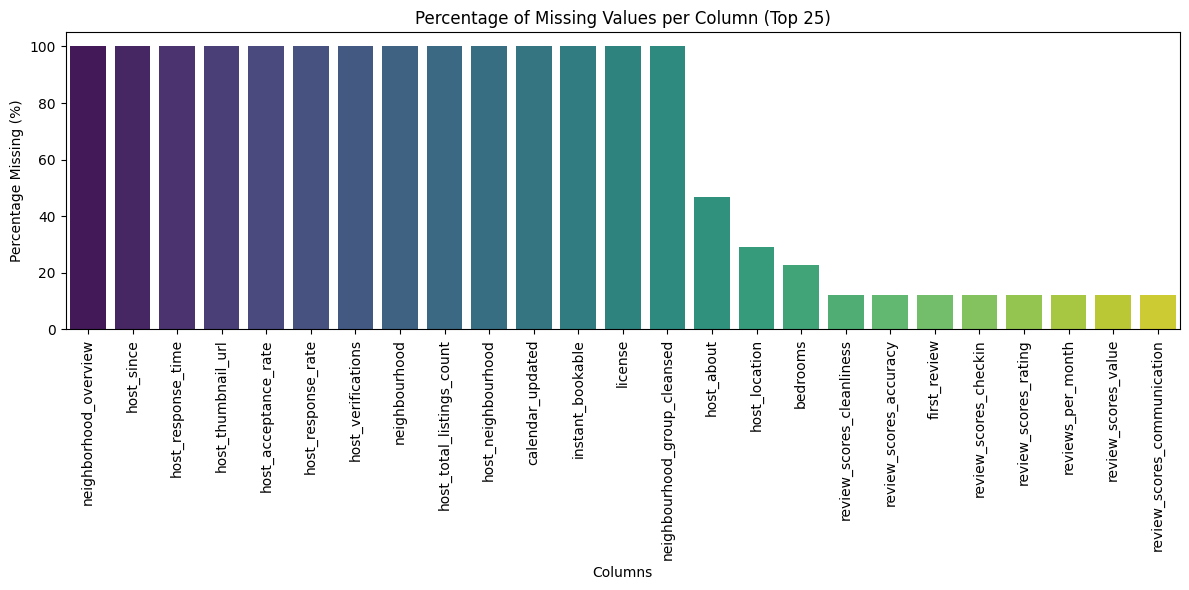

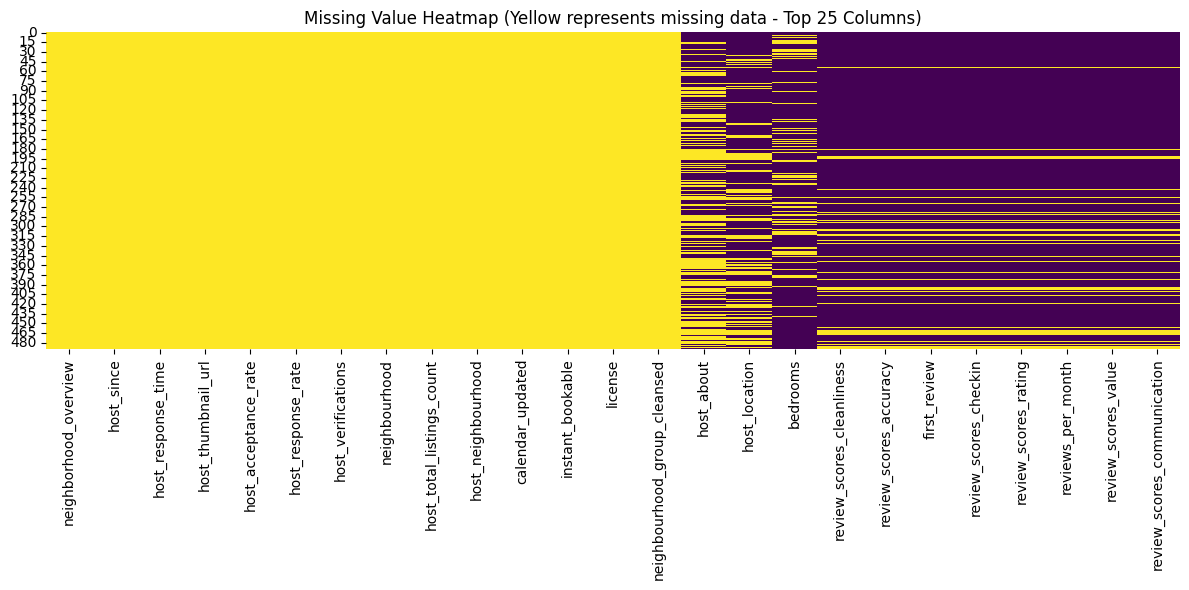

In [5]:
# 🔧 2.1. Count the null values of each column
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a DataFrame to display the top missing columns
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage (%)': missing_percentage
}).sort_values(by='Missing Count', ascending=False)

print("--- Top 20 Columns with Most Missing Values ---")
display(missing_df.head(20))

# 🔧 2.2. Create visuals to help show what columns are missing values
# Filter columns that have at least one missing value for better visualization
columns_with_missing = missing_df[missing_df['Missing Count'] > 0]

if not columns_with_missing.empty:
    # 1. Bar Chart of Missing Percentages
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=columns_with_missing.index[:25],
        y=columns_with_missing['Percentage (%)'][:25],
        palette='viridis'
    )
    plt.title('Percentage of Missing Values per Column (Top 25)')
    plt.xlabel('Columns')
    plt.ylabel('Percentage Missing (%)')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    # 2. Heatmap of Missingness for columns with missing values
    plt.figure(figsize=(12, 6))
    sns.heatmap(df[columns_with_missing.index[:25]].isnull(), cbar=False, cmap='viridis')
    plt.title('Missing Value Heatmap (Yellow represents missing data - Top 25 Columns)')
    plt.tight_layout()
    plt.show()
else:
    print("Great news! There are no missing values in the dataset.")

### ✍️ Please answer the following:

2.3. What are the top 3 columns with the most missing values?

2.4. Which columns are likely to create business issues?

2.5. Which columns could be safely ignored or dropped?


### ✍️ Your Response:

2.3. The top 3 columns are neighborhood_overview, host_since, and host_response_time. They are all 100% missing.

2.4. host_response_rate, host_acceptance_rate, and instant_bookable may cause business issues because this information can help us understand the hosts and listings.

2.5. Columns with 100% missing values can be dropped because they do not have any data. For example, host_thumbnail_url, calendar_updated, and neighbourhood.


## **Task 3. Drop Columns That Aren’t Useful**

Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

Make a decision:

3.1. Choose 2-4 columns to drop from your dataset, and drop them.

3.2. Confirm they're gone with `.head()` or `.info()`



In [6]:
# 🔧 3.1. Choose 2-4 columns to drop from your dataset, and drop them.
columns_to_drop = ['calendar_updated', 'license']
df = df.drop(columns=columns_to_drop)

# 🔧 3.2. Confirm they're gone with .head() or .info()
print("Columns after dropping:", df.columns.tolist())
print(f"New dataset shape: {df.shape}")
display(df.head())

Columns after dropping: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price_

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20260616211424,2026-06-16,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.22,4.56,3.22,3.67,NaN,1,1,0,0,0.06
1,3820211,https://www.airbnb.com/rooms/3820211,20260616211424,2026-06-16,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.85,4.81,4.82,4.78,NaN,7,7,0,0,2.20
2,5651579,https://www.airbnb.com/rooms/5651579,20260616211424,2026-06-16,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",NaN,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.81,4.87,4.75,4.63,NaN,2,1,1,0,3.00
3,6623339,https://www.airbnb.com/rooms/6623339,20260616211424,2026-06-16,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.83,4.70,4.80,4.72,NaN,7,7,0,0,2.47
4,9501054,https://www.airbnb.com/rooms/9501054,20260616211424,2026-06-16,city scrape,Spacious suite with full bath by Capital Center,Great location within walking distance to the ...,NaN,https://a0.muscache.com/pictures/45153167-d704...,29288920,...,4.84,4.87,4.77,4.68,NaN,2,1,1,0,3.71


### ✍️ Please answer the following:

3.3. Which columns did you drop?

3.4. Why were they not useful from a business perspective?

3.5. What could go wrong if you left them in?

### ✍️ Your Response: 🔧
3.3. I dropped calendar_updated and license.

3.4. These columns were not useful because they had no data to use.

3.5. If I kept them, they could make the data more confusing and would not help with the analysis.



## **Task 4. Fill or Fix Values in Key Columns**

Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

4.1. Choose 2 columns with missing values
- Use a strategy to fill or flag those values (e.g., median, “unknown”, forward-fill, or a placeholder)

4.2. Write a command to ensure that the missing values have been addressed.


In [7]:
# 🔧 4.1. Your code for taking care of missing values for 2 columns
# We will use the median of 'bedrooms' to fill missing bedroom counts
bedrooms_median = df['bedrooms'].median()
df['bedrooms'] = df['bedrooms'].fillna(bedrooms_median)

# We will use the median of 'review_scores_rating' to fill its missing values
rating_median = df['review_scores_rating'].median()
df['review_scores_rating'] = df['review_scores_rating'].fillna(rating_median)

# 🔧 4.2. Your code to verify that missing values have been addressed in the 2 columns
print(f"Missing values remaining in 'bedrooms': {df['bedrooms'].isnull().sum()}")
print(f"Missing values remaining in 'review_scores_rating': {df['review_scores_rating'].isnull().sum()}")

Missing values remaining in 'bedrooms': 0
Missing values remaining in 'review_scores_rating': 0


### ✍️ Please answer the following:

4.3. What two columns did you choose to address missing values in?

4.4. What method did you use for each, and why?

4.5. What risks are there in how you filled the data?

### ✍️ Your Response:
4.3. I chose bedrooms and review_scores_rating.

4.4. I used the median for both because it is a simple way to fill in the missing values and is not affected much by very high or low values.

4.5. The filled values may not be the real values, so the results may not be completely accurate.


## **Task 5. Convert and Clean Data Types**

Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

5.1. Identify one column with the wrong data type
- Convert it into a usable format (e.g., from string to number)

5.2. Verify that the data type was changed



In [8]:
# 🔧 5.1. Change data type
# Inspect the first few raw values first
print("Before conversion (sample values):", df['price'].head())

# Clean string values (remove '$' and ',') and convert to float
df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip()
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# 🔧 5.2. Verify Change data type
print("\nAfter conversion (sample values):", df['price'].head())
print("New data type of 'price':", df['price'].dtype)

Before conversion (sample values): 0     $80.43
1    $211.00
2     $97.00
3    $160.00
4     $86.00
Name: price, dtype: object

After conversion (sample values): 0     80.43
1    211.00
2     97.00
3    160.00
4     86.00
Name: price, dtype: float64
New data type of 'price': float64


### ✍️ Please answer the following:

5.3. What column did you fix?

5.4. What cleaning steps did you apply?

5.5. How does this help prepare the data for later use?

### ✍️ Your Response: 🔧

5.3. I fixed the price column.

5.4. I removed the $ sign and changed the values into numbers.

5.5. This makes the price easier to calculate and use later.

## **Task 6. Remove Duplicate Records**

Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

6.1. Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs

6.2. Remove duplicates if found - keep only one instance of each set of the duplicated rows



In [9]:
# 🔧 6.1. Check for exact duplicate rows and duplicate IDs
# Count exact duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of exact duplicate rows in the dataset: {duplicate_rows}")

# Count duplicate IDs (since each listing should have a unique 'id')
duplicate_ids = df.duplicated(subset=['id']).sum()
print(f"Number of duplicate listing IDs: {duplicate_ids}")

# 🔧 6.2. Remove duplicates if found
# Save the initial shape
initial_shape = df.shape

if duplicate_ids > 0:
    # Drop duplicates based on 'id', keeping the first instance
    df = df.drop_duplicates(subset=['id'], keep='first')
    print(f"\nRemoved duplicates. Dataset shape changed from {initial_shape} to {df.shape}.")
else:
    print("\nNo duplicate records based on 'id' were found. No rows needed to be removed.")

Number of exact duplicate rows in the dataset: 0
Number of duplicate listing IDs: 0

No duplicate records based on 'id' were found. No rows needed to be removed.


### ✍️ Please answer the following:

6.3. Did you find duplicates?

6.4. How did you decide what to drop or keep?

6.5. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response:

6.3. No, I did not find any duplicates.

6.4. Since there were no duplicates, I did not need to drop any rows.

6.5. Duplicates can make the data incorrect because the same listing may be counted more than once.

## **Task 7. Export Cleaned Data**

Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed


7.1. Before wrapping up, export your cleaned Airbnb dataset to a CSV file.

```
# Steps:
# - use df.to_csv(filename, index)
# - parameter filename = "cleaned_airbnb_data.csv" is the name of the file that will be saved
# - parameter index = False prevents pandas from writing an extra column of row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```

You'll need this file for **Assignment 7**, where you'll perform data transformation techniques. This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.






In [10]:
# 🔧 7.1. Export csv here
# Save the cleaned DataFrame to a CSV file without the index
df.to_csv("cleaned_airbnb_data.csv", index=False)

print("Cleaned dataset has been successfully exported as 'cleaned_airbnb_data.csv'!")
print("You can open the left sidebar, click the folder icon 📁, and download the file.")

Cleaned dataset has been successfully exported as 'cleaned_airbnb_data.csv'!
You can open the left sidebar, click the folder icon 📁, and download the file.


## **Task 8. Final Reflection**

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### ✍️ Please answer the following:

8.1. What was the most surprising or challenging part of cleaning this dataset?

8.2. How did you decide which data to drop, fix, or keep?

8.3. What’s one way a business team (e.g., hosts, pricing analysts, platform ops) might benefit from the cleaned version of this data?

8.4. If you had more time, what would you explore or clean further?

8.5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

8.1. The hardest part was dealing with missing values because some columns had a lot of missing data.

8.2. I dropped columns with no useful data, fixed some missing values, and kept the useful columns.

8.3. The cleaned data can help the business team understand the listings and prices better.

8.4. If I had more time, I would check more columns and see if there are other data problems.

8.5. This relates to my learning outcome because I learned how to clean and check data before doing analysis.


## Submission Instructions
✅ Checklist:
- Make sure all code cells are run and outputs are visible  
- All markdown/comment questions are answered thoughtfully  
- Save the file with your last name and first name as shown below (see detailed instructions in Lab 1 on how to do this).
- Submit the assignment as an **HTML file** on Canvas

In [14]:
!jupyter nbconvert --to html "assignment_06_Gong Linlin.ipynb"

[NbConvertApp] Converting notebook assignment_06_Gong Linlin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 572420 bytes to assignment_06_Gong Linlin.html
